Goal of this notebook: create a similar plot with:

- aggregated summer precipitation
- aggregated summer temperatures

Choices:
- which temperature variable? --> for now, daily mean.
- what to do with precip on "dry" days (set to zero?) --> for now, nothing.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

import cmcrameri as cmc  # noqa: F401

import seaborn as sns
import yaml
from scipy.stats import false_discovery_control
import os
from metpy.units import units

from unseen_awg.plotting_utils import (
    map_plot_without_frame_with_bounds,
    add_headers,
    add_label_to_axes,
)

import cartopy.crs as ccrs
from matplotlib import gridspec
from analyses.utils import (
    extract_n_years_from_trajectory,
    load_trajectories,
    extract_datapoints_in_years,
    extract_datapoints_in_months,
    stack_to_dim,
)
import matplotlib as mpl

In [3]:
mpl.rc_file("../../matplotlibrc")
ALPHABET = "abcdefghijklmn"

In [4]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [5]:
N_YEARS = 21

YEAR_MIN = 2003
YEAR_MAX = YEAR_MIN + N_YEARS - 1

# COORDS_LEIPZIG =
COORDS_TEST = {
    "latitude": 51.340199,  # 54,  # 34.963726,  #30.2,  #
    "longitude": 12.360103,  # 3.3,  # 13.999314,  #39.8,  #
}  # {"longitude":33.947754, "latitude":43.157109}  # {"longitude": 0, "latitude": 51.509865}  # {"latitude":30.2, "longitude":-9.8}  #   # {"latitude": 48.21, "longitude": 16.37}

JJA = np.array([6, 7, 8])
JULY = np.array([7])

In [6]:
path_rechunked_era5 = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_impact_variables_era5",
    "rechunk_combined_facc0e91.zarr",
)
path_rechunked_reforecasts = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_impact_variables_reforecasts",
    "rechunk_combined_7d1d3d97.zarr",
)
path_rechunked_reforecasts_bias_corrected = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_impact_variables_reforecasts",
    "rechunk_combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d.zarr",
)


ds_era5 = xr.open_zarr(
    path_rechunked_era5,
    decode_timedelta=True,
)
ds_reforecasts = xr.open_zarr(
    path_rechunked_reforecasts,
    decode_timedelta=True,
)
ds_reforecasts_debiased = xr.open_zarr(
    path_rechunked_reforecasts_bias_corrected,
    decode_timedelta=True,
)

ds_era5["tp"] = (
    ds_era5["tp"]
    .where(ds_era5["tp"].metpy.quantify() > 1 * units.millimeter, 0)
    .metpy.dequantify()
)
ds_reforecasts["tp"] = (
    ds_reforecasts["tp"]
    .where(ds_reforecasts["tp"].metpy.quantify() > 1 * units.millimeter, 0)
    .metpy.dequantify()
)
ds_reforecasts_debiased["tp"] = (
    ds_reforecasts_debiased["tp"]
    .where(ds_reforecasts_debiased["tp"].metpy.quantify() > 1 * units.millimeter, 0)
    .metpy.dequantify()
)

ds_era5 = ds_era5.assign_coords({"valid_time": ds_era5.init_time + ds_era5.lead_time})
ds_reforecasts = ds_reforecasts.assign_coords(
    {"valid_time": ds_reforecasts.init_time + ds_reforecasts.lead_time}
)
ds_reforecasts_debiased = ds_reforecasts_debiased.assign_coords(
    {
        "valid_time": ds_reforecasts_debiased.init_time
        + ds_reforecasts_debiased.lead_time
    }
)

datasets = {
    "Reforecasts": ds_reforecasts,
    "Reforecasts bias-corrected": ds_reforecasts_debiased,
    "ERA5_2003_2023": ds_era5,
}

In [7]:
MONTHS = JJA  # JJA

dir_selected_simulations = "wg_reforecasts_5e06172f_f40e9460_1e69bda9_d13ad10f"
sigma = 2.5
n_seeds = 100
blocksizes = [1, 7, 14, 30, 44]

paths_trajectories = [
    os.path.join(
        paths["dir_simulations"],
        dir_selected_simulations,
        f"{seed}_{sigma:g}_{blocksize}",
    )
    for (seed, blocksize) in product(np.arange(n_seeds), blocksizes)
]

TRAJECTORIES = {
    "Reforecasts": {
        "paths": paths_trajectories,
        "dataset": "Reforecasts",
    },
    "Reforecasts bias-corrected": {
        "paths": paths_trajectories,
        "dataset": "Reforecasts bias-corrected",
    },
    # "ERA5_2003_2023": {
    #     "path": os.path.join(paths.dir_simulations, "trajectories_ERA5_2003_2023_500"),
    #     "WG": "ERA5_2003_2023",
    #     "dataset": "ERA5_2003_2023",
    # },
}

ground_truth = (
    extract_datapoints_in_years(
        stack_to_dim(ds_era5),
        year_max=YEAR_MAX,
        year_min=YEAR_MIN,
    ).swap_dims({"datapoint": "valid_time"})
).sel(COORDS_TEST, method="nearest")

print("compute aggregates for ground truth")
tp_gt = (
    extract_datapoints_in_months(ground_truth["tp"], months=MONTHS)
    .groupby("valid_time.year")
    .sum()
    .load()
)
t2m_gt = (
    extract_datapoints_in_months(ground_truth["t2m"], months=MONTHS)
    .groupby("valid_time.year")
    .mean()
    .load()
)

datasets_trajs = []

for k, traj_config in TRAJECTORIES.items():
    trajectories = load_trajectories(traj_config["paths"])

    print("load trajectories")
    trimmed_trajs = []
    for traj in trajectories:
        trimmed_trajs.append(
            extract_n_years_from_trajectory(
                traj=traj,
                n_years=N_YEARS,
                new_start_year=ground_truth.valid_time.dt.year.min().data,
            )
        )

    trimmed_trajs = xr.combine_by_coords(trimmed_trajs).isel(seed=slice(None, 100))

    datasets_trajs.append(
        (
            datasets[traj_config["dataset"]]
            .sel(COORDS_TEST, method="nearest")
            .drop_vars("valid_time")
            .sel(trimmed_trajs.load())
            .rename({"out_time": "valid_time"})
            .expand_dims({"dataset": [traj_config["dataset"]]})
        )
    )

print("merge datasets")
datasets_trajs = xr.combine_by_coords(datasets_trajs)

compute aggregates for ground truth
load trajectories
load trajectories
merge datasets


In [8]:
t2m_summer_trajs = (
    extract_datapoints_in_months(datasets_trajs, MONTHS)["t2m"]
    .groupby("valid_time.year")
    .mean()
    .load()
)
tp_summer_trajs = (
    extract_datapoints_in_months(datasets_trajs, MONTHS)["tp"]
    .groupby("valid_time.year")
    .sum()
    .load()
)

t2m_ground_truth = (
    extract_datapoints_in_months(ground_truth, MONTHS)["t2m"]
    .groupby("valid_time.year")
    .mean()
    .load()
)
tp_ground_truth = (
    extract_datapoints_in_months(ground_truth, MONTHS)["tp"]
    .groupby("valid_time.year")
    .sum()
    .load()
)

/tmp/ipykernel_1227719/4213841667.py:87: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon_or = plt.Polygon(
/tmp/ipykernel_1227719/4213841667.py:95: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon_and = plt.Polygon(


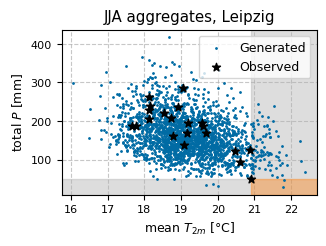

In [9]:
plt.figure(figsize=(3.15, 2.35))  # half of regular size in each dimension

ax = plt.gca()

# weather generators

blocksize = 30

for dataset in t2m_summer_trajs.dataset:
    if dataset == "Reforecasts bias-corrected":
        plt.scatter(
            t2m_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=blocksize,
                sigma=slice(0, None),
            ),
            tp_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=blocksize,
                sigma=slice(0, None),
            ),
            label="Generated",  # f"Generated {dataset.data}",  #
            s=1,
            zorder=3,
        )

# ground truth
plt.scatter(
    t2m_ground_truth, tp_ground_truth, label="Observed", marker="*", color="k", zorder=4
)

HOTTEST_DRIEST_patch = np.array(
    [
        [
            t2m_ground_truth.max("year").data,
            tp_ground_truth.min("year").data,
        ],
        [
            t2m_ground_truth.max("year").data,
            ax.get_ylim()[0],
        ],
        [
            ax.get_xlim()[1],
            ax.get_ylim()[0],
        ],
        [
            ax.get_xlim()[1],
            tp_ground_truth.min("year").data,
        ],
    ]
)

HOTTEST_DRIEST_or_patch = np.array(
    [
        # Start at bottom-left corner
        [
            ax.get_xlim()[0],
            ax.get_ylim()[0],
        ],
        # Go up to driest precipitation point (left edge)
        [
            ax.get_xlim()[0],
            tp_ground_truth.min("year").data,
        ],
        [
            t2m_ground_truth.max("year").data,
            tp_ground_truth.min("year").data,
        ],
        [
            t2m_ground_truth.max("year").data,
            ax.get_ylim()[1],
        ],
        [
            ax.get_xlim()[1],
            ax.get_ylim()[1],
        ],
        [
            ax.get_xlim()[1],
            ax.get_ylim()[0],
        ],
    ]
)

# Create the OR polygon patch
polygon_or = plt.Polygon(
    HOTTEST_DRIEST_or_patch, color="C2", alpha=0.4, edgecolor="none", zorder=1
)

ax.add_patch(polygon_or)


# Create a polygon patch
polygon_and = plt.Polygon(
    HOTTEST_DRIEST_patch, color="C1", alpha=0.4, edgecolor="none", zorder=2
)

ax.add_patch(polygon_and)

# plt.title(f"Months {MONTHS}, elemental timestep: {blocksize}")

plt.title("JJA aggregates, Leipzig")

plt.xlabel(r"mean $T_{2m}$ [°C]")
plt.ylabel(r"total $P$ [mm]")
plt.legend()

plt.savefig(os.path.join(paths["dir_images"], "hot_dry_testpoint.pdf"), dpi=300)

In [10]:
dir_runs_wg = os.path.join(
    paths["dir_results"], "seasonal_correlation", "5e06172f_f40e9460_1e69bda9_d13ad10f"
)

# bias corrected data
run = "b6e7334d_3607a6cc"

pearsonr = xr.open_dataarray(
    os.path.join(dir_runs_wg, run, "tas_pr_pearsonr.nc")
).squeeze("variable")
pearsonp = xr.open_dataarray(
    os.path.join(dir_runs_wg, run, "tas_pr_pearsonp.nc")
).squeeze("variable")
spearmanr = xr.open_dataarray(
    os.path.join(dir_runs_wg, run, "tas_pr_spearmanr.nc")
).squeeze("variable")
spearmanp = xr.open_dataarray(
    os.path.join(dir_runs_wg, run, "tas_pr_spearmanp.nc")
).squeeze("variable")

In [11]:
fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(
    len(pearsonp.blocksize) + 1,
    1,
    height_ratios=(len(pearsonp.blocksize))
    * [
        1,
    ]
    + [0.1],
)  # The last row is for the colorbar


cax = fig.add_subplot(gs[-1, 0])

for i, tau in enumerate(pearsonr.blocksize.sel(blocksize=slice(0, None))):
    ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())

    if i == 0:
        map_plot_without_frame_with_bounds(
            ax=ax,
            da=pearsonr.transpose()
            .sel(blocksize=tau, WG="Generated", sigma=2.5)
            .mean("seed"),
            cmap="RdBu_r",
            vmin=-0.8,
            vmax=0.8,
            cbar_ax=cax,
            cbar_kwargs={"orientation": "horizontal", "label": r"$r$"},
        )
    else:
        map_plot_without_frame_with_bounds(
            ax=ax,
            da=pearsonr.transpose()
            .sel(blocksize=tau, WG="Generated", sigma=2.5)
            .mean("seed"),
            cmap="RdBu_r",
            vmin=-0.8,
            vmax=0.8,
            add_colorbar=False,
        )
    ax.coastlines()
    ax.set_title(r"$WG_{reforecast}$, $\tau:$ " + f"{tau.data}")

fig.suptitle("Mean of summer correlation coeffs\nover different random seeds")
plt.savefig(os.path.join(paths["dir_images"], "seasonal_correlation_maps_mean.png"))
plt.close()

/tmp/ipykernel_1227719/435528153.py:45: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(os.path.join(paths["dir_images"], "seasonal_correlation_maps_mean.png"))
/tmp/ipykernel_1227719/435528153.py:45: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(os.path.join(paths["dir_images"], "seasonal_correlation_maps_mean.png"))


In [12]:
fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(
    len(pearsonp.blocksize) + 1,
    1,
)  # The last row is for the colorbar

density = 7

for i, tau in enumerate(pearsonr.blocksize.sel(blocksize=slice(0, None))):
    ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())
    map_plot_without_frame_with_bounds(
        ax=ax,
        da=pearsonr.transpose()
        .sel(blocksize=tau, WG="Generated", sigma=2.5)
        .sel(seed=0),
        robust=True,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        add_colorbar=False,
    )
    ax.coastlines()
    ax.set_title(r"$WG_{reforecast}$, $\tau:$ " + f"{tau.data}")

ax = fig.add_subplot(gs[-1, 0], projection=ccrs.Robinson())

map_plot_without_frame_with_bounds(
    ax=ax,
    da=pearsonr.transpose().sel(blocksize=-1, WG="Ground Truth", sigma=-1).sel(seed=-1),
    robust=True,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    add_colorbar=False,
)
ax.set_title(r"Ground Truth")
ax.coastlines()

fig.suptitle("Summer correlation coeffs for\n20 year time series")
plt.savefig(
    os.path.join(paths["dir_images"], "seasonal_correlation_maps_mean_sample.png")
)
plt.close()

/tmp/ipykernel_1227719/3680558524.py:40: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/tmp/ipykernel_1227719/3680558524.py:40: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(


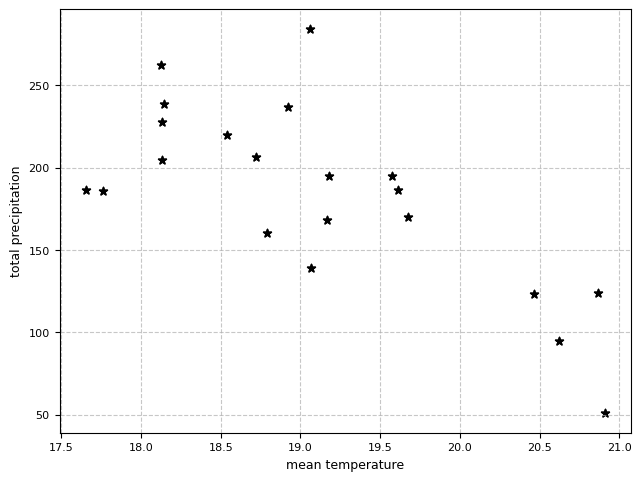

In [13]:
tau = 44
for dataset in t2m_summer_trajs.dataset:
    # plt.scatter(
    #     t2m_summer_trajs.sel(
    #         WG=wg,
    #         seed=slice(0, None),
    #         blocksize=tau,
    #         sigma=slice(0, None),
    #     ),
    #     tp_summer_trajs.sel(
    #         WG=wg,
    #         seed=slice(0, None),
    #         blocksize=tau,
    #         sigma=slice(0, None),
    #     ),
    #     label="Generated",  # label=f"{wg.data}",
    #     s=1,
    # )

    # ground truth
    plt.scatter(
        t2m_ground_truth,
        tp_ground_truth,
        label=r"Observed $ERA5_{2003-2023}$",
        marker="*",
        color="k",
    )
plt.ylabel("total precipitation")
plt.xlabel("mean temperature")

# plt.xlim((16, 23))
# plt.ylim((0, 400))
plt.show()
plt.close()

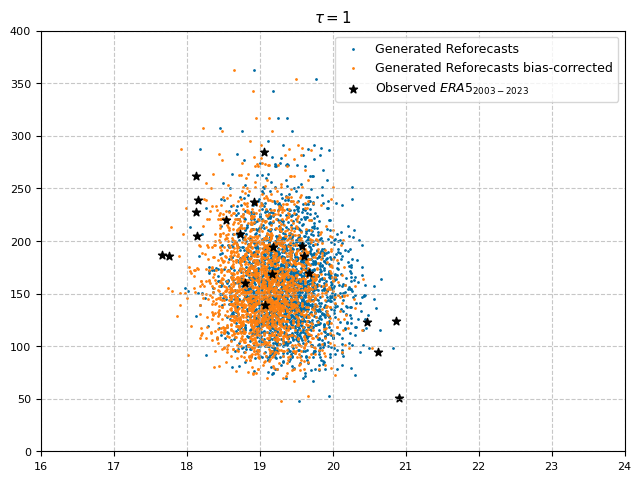

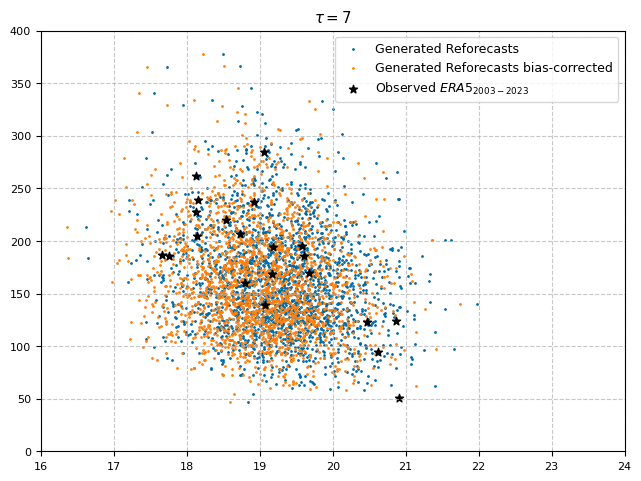

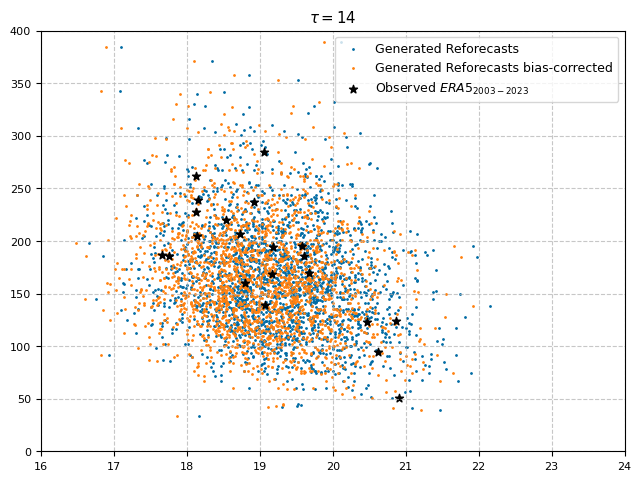

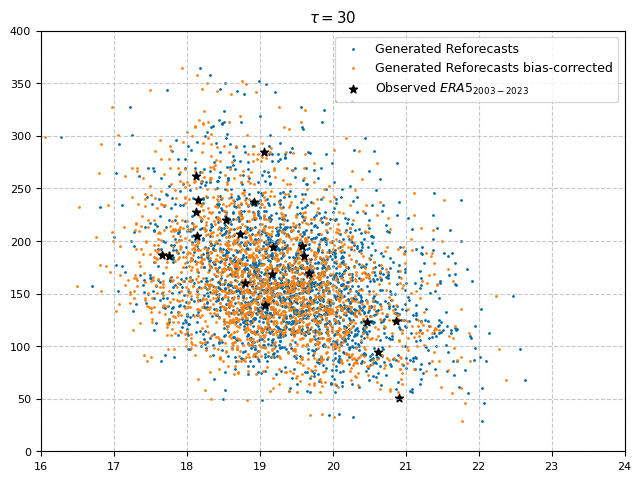

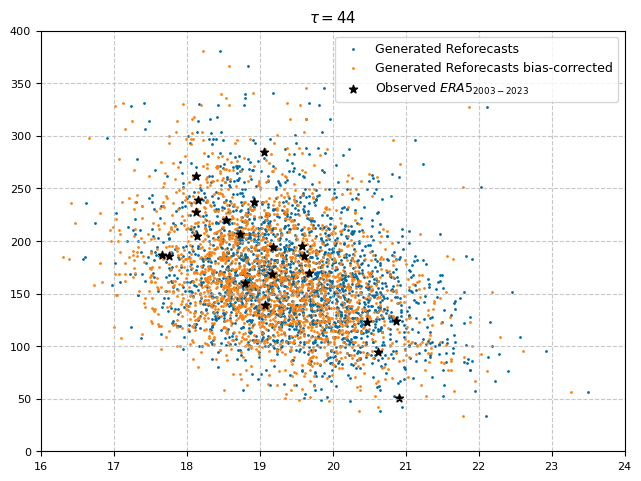

In [14]:
for tau in t2m_summer_trajs.blocksize:
    for dataset in t2m_summer_trajs.dataset:
        plt.scatter(
            t2m_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=tau,
                sigma=slice(0, None),
            ),
            tp_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=tau,
                sigma=slice(0, None),
            ),
            label=f"Generated {dataset.data}",  # label=f"{wg.data}",
            s=1,
        )

    # ground truth
    plt.scatter(
        t2m_ground_truth,
        tp_ground_truth,
        label=r"Observed $ERA5_{2003-2023}$",
        marker="*",
        color="k",
    )
    plt.title(r"$\tau = $" + f"{tau.data}")

    plt.xlim((16, 24))
    plt.legend()
    plt.ylim((0, 400))
    # plt.yscale("log")
    plt.show()

## How close is the generated distribution to the real distribution?

This part is not used right now because it is compute&memory intensive.

In [15]:
"""
runs = {
    "WG ERA5": "f3d1f2f7_6e629cd9_7560715e_d13ad10f/d3ba1746_f34a7358",
    # "WG Reforecasts": "5e06172f_f40e9460_1e69bda9_d13ad10f/162db1e0_a3747d05",
    "WG Reforecasts\nbias-corrected": "5e06172f_f40e9460_1e69bda9_d13ad10f/dfd05201_a3df13e4",
}

energy_distances = {}
p_values_energy_distance = {}
for label, run in runs.items():
    # load data
    energy_distances[label] = xr.open_dataarray(
        os.path.join(
            paths["dir_results"],
            "seasonal_correlation",
            f"{run}/e_dist.nc",
        )
    )
    p_values_energy_distance[label] = xr.open_dataarray(
        os.path.join(
            paths["dir_results"],
            "seasonal_correlation",
            f"{run}/p_value_e_dist.nc",
        )
    )
"""

'\nruns = {\n    "WG ERA5": "f3d1f2f7_6e629cd9_7560715e_d13ad10f/d3ba1746_f34a7358",\n    # "WG Reforecasts": "5e06172f_f40e9460_1e69bda9_d13ad10f/162db1e0_a3747d05",\n    "WG Reforecasts\nbias-corrected": "5e06172f_f40e9460_1e69bda9_d13ad10f/dfd05201_a3df13e4",\n}\n\nenergy_distances = {}\np_values_energy_distance = {}\nfor label, run in runs.items():\n    # load data\n    energy_distances[label] = xr.open_dataarray(\n        os.path.join(\n            paths["dir_results"],\n            "seasonal_correlation",\n            f"{run}/e_dist.nc",\n        )\n    )\n    p_values_energy_distance[label] = xr.open_dataarray(\n        os.path.join(\n            paths["dir_results"],\n            "seasonal_correlation",\n            f"{run}/p_value_e_dist.nc",\n        )\n    )\n'

In [16]:
"""
vmin = 0  # energy_distance.min()
vmax = 0.4  # energy_distance.max()

fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(
    len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize) + 1,
    len(energy_distances.keys()),
    height_ratios=len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize)
    * [
        1,
    ]
    + [0.1],
)

ax_cbar = fig.add_subplot(gs[-1, :])

for j, (label, energy_distance) in enumerate(energy_distances.items()):
    for i, tau in enumerate(energy_distance.blocksize.sel(blocksize=slice(0, None))):
        ax = fig.add_subplot(gs[i, j], projection=ccrs.Robinson())
        if i == 0:
            map_plot_without_frame_with_bounds(
                ax=ax,
                da=energy_distance.transpose().sel(blocksize=tau).squeeze(),
                robust=True,
                vmin=vmin,
                vmax=vmax,
                add_colorbar=True,
                cbar_ax=ax_cbar,
                cbar_kwargs={"orientation": "horizontal"},
            )
        else:
            map_plot_without_frame_with_bounds(
                ax=ax,
                da=energy_distance.transpose().sel(blocksize=tau).squeeze(),
                robust=True,
                vmin=vmin,
                vmax=vmax,
                add_colorbar=False,
            )
        ax.coastlines()
        ax.set_title(r"")

fig.suptitle("Energy distance")

font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    row_headers=[rf"$\tau$={tau.data}" for tau in energy_distance["blocksize"]] + [""],
    col_headers=[k for k in energy_distances.keys()],
    col_pad=50,
    **font_kwargs,
)
plt.savefig(os.path.join(paths["dir_images"], "energy_distance.png"))
plt.close()
"""

'\nvmin = 0  # energy_distance.min()\nvmax = 0.4  # energy_distance.max()\n\nfig = plt.figure(figsize=(8, 12))\ngs = gridspec.GridSpec(\n    len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize) + 1,\n    len(energy_distances.keys()),\n    height_ratios=len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize)\n    * [\n        1,\n    ]\n    + [0.1],\n)\n\nax_cbar = fig.add_subplot(gs[-1, :])\n\nfor j, (label, energy_distance) in enumerate(energy_distances.items()):\n    for i, tau in enumerate(energy_distance.blocksize.sel(blocksize=slice(0, None))):\n        ax = fig.add_subplot(gs[i, j], projection=ccrs.Robinson())\n        if i == 0:\n            map_plot_without_frame_with_bounds(\n                ax=ax,\n                da=energy_distance.transpose().sel(blocksize=tau).squeeze(),\n                robust=True,\n                vmin=vmin,\n                vmax=vmax,\n                add_colorbar=True,\n                cbar_ax=ax_cbar,\n                cbar_kwar

In [17]:
"""
vmin = 0  # energy_distance.min()
vmax = 0.05  # energy_distance.max()

fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(
    len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize) + 1,
    len(energy_distances.keys()),
    height_ratios=len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize)
    * [
        1,
    ]
    + [0.1],
)

ax_cbar = fig.add_subplot(gs[-1, :])

for j, (label, p_value_energy_distance) in enumerate(p_values_energy_distance.items()):
    for i, tau in enumerate(
        p_value_energy_distance.blocksize.sel(blocksize=slice(0, None))
    ):
        ax = fig.add_subplot(gs[i, j], projection=ccrs.Robinson())
        if i == 0:
            map_plot_without_frame_with_bounds(
                ax=ax,
                da=p_value_energy_distance.transpose().sel(blocksize=tau).squeeze(),
                robust=True,
                vmin=vmin,
                vmax=vmax,
                add_colorbar=True,
                cbar_ax=ax_cbar,
                cbar_kwargs={"orientation": "horizontal"},
            )
        else:
            map_plot_without_frame_with_bounds(
                ax=ax,
                da=p_value_energy_distance.transpose().sel(blocksize=tau).squeeze(),
                robust=True,
                vmin=vmin,
                vmax=vmax,
                add_colorbar=False,
            )
        ax.coastlines()
        ax.set_title(r"")

fig.suptitle("p-values Energy distance")

font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    row_headers=[rf"$\tau$={tau.data}" for tau in energy_distance["blocksize"]] + [""],
    col_headers=[k for k in energy_distances.keys()],
    col_pad=50,
    **font_kwargs,
)
plt.savefig(os.path.join(paths["dir_images"], "energy_distance_p_values.png"))
plt.close()
"""

'\nvmin = 0  # energy_distance.min()\nvmax = 0.05  # energy_distance.max()\n\nfig = plt.figure(figsize=(8, 12))\ngs = gridspec.GridSpec(\n    len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize) + 1,\n    len(energy_distances.keys()),\n    height_ratios=len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize)\n    * [\n        1,\n    ]\n    + [0.1],\n)\n\nax_cbar = fig.add_subplot(gs[-1, :])\n\nfor j, (label, p_value_energy_distance) in enumerate(p_values_energy_distance.items()):\n    for i, tau in enumerate(\n        p_value_energy_distance.blocksize.sel(blocksize=slice(0, None))\n    ):\n        ax = fig.add_subplot(gs[i, j], projection=ccrs.Robinson())\n        if i == 0:\n            map_plot_without_frame_with_bounds(\n                ax=ax,\n                da=p_value_energy_distance.transpose().sel(blocksize=tau).squeeze(),\n                robust=True,\n                vmin=vmin,\n                vmax=vmax,\n                add_colorbar=True,\n          

In [18]:
"""
for label, energy_distance in energy_distances.items():
    energy_distance.mean(("latitude", "longitude")).squeeze().plot(label=label)
plt.legend()
plt.xlabel("Elemental timestep [d]")
plt.ylabel("Energy distance")
plt.title(
    "Spatial mean energy distance to generated summer $T_{2m}$ and total precipitation"
)
"""

'\nfor label, energy_distance in energy_distances.items():\n    energy_distance.mean(("latitude", "longitude")).squeeze().plot(label=label)\nplt.legend()\nplt.xlabel("Elemental timestep [d]")\nplt.ylabel("Energy distance")\nplt.title(\n    "Spatial mean energy distance to generated summer $T_{2m}$ and total precipitation"\n)\n'

In [19]:
"""
fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(
    len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize) + 1,
    1,
    height_ratios=len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize)
    * [
        1,
    ]
    + [0.1],
)

vmin = 0
vmax = 2

ax_cbar = fig.add_subplot(gs[-1])


for i, tau in enumerate(energy_distance.blocksize.sel(blocksize=slice(0, None))):
    ax = fig.add_subplot(gs[i], projection=ccrs.Robinson())
    if i == 0:
        map_plot_without_frame_with_bounds(
            ax=ax,
            da=(
                energy_distances["WG Reforecasts\nbias-corrected"]
                / energy_distances["WG Reforecasts"]
            )
            .transpose()
            .sel(blocksize=tau)
            .squeeze(),
            vmin=vmin,
            vmax=vmax,
            cmap="RdBu_r",
            robust=True,
            add_colorbar=True,
            cbar_ax=ax_cbar,
            cbar_kwargs={"orientation": "horizontal"},
        )
    else:
        map_plot_without_frame_with_bounds(
            ax=ax,
            da=(
                energy_distances["WG Reforecasts\nbias-corrected"]
                / energy_distances["WG Reforecasts"]
            )
            .transpose()
            .sel(blocksize=tau)
            .squeeze(),
            vmin=vmin,
            vmax=vmax,
            cmap="RdBu_r",
            robust=True,
            add_colorbar=False,
        )
    ax.coastlines()
    ax.set_title(r"")

fig.suptitle("Ratio energy distance before and after bias correction")

font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    row_headers=[rf"$\tau$={tau.data}" for tau in energy_distance["blocksize"]] + [""],
    # col_headers=[k for k in energy_distances.keys()],
    col_pad=50,
    **font_kwargs,
)
"""

'\nfig = plt.figure(figsize=(8, 12))\ngs = gridspec.GridSpec(\n    len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize) + 1,\n    1,\n    height_ratios=len(energy_distances["WG Reforecasts\nbias-corrected"].blocksize)\n    * [\n        1,\n    ]\n    + [0.1],\n)\n\nvmin = 0\nvmax = 2\n\nax_cbar = fig.add_subplot(gs[-1])\n\n\nfor i, tau in enumerate(energy_distance.blocksize.sel(blocksize=slice(0, None))):\n    ax = fig.add_subplot(gs[i], projection=ccrs.Robinson())\n    if i == 0:\n        map_plot_without_frame_with_bounds(\n            ax=ax,\n            da=(\n                energy_distances["WG Reforecasts\nbias-corrected"]\n                / energy_distances["WG Reforecasts"]\n            )\n            .transpose()\n            .sel(blocksize=tau)\n            .squeeze(),\n            vmin=vmin,\n            vmax=vmax,\n            cmap="RdBu_r",\n            robust=True,\n            add_colorbar=True,\n            cbar_ax=ax_cbar,\n            cbar_kwargs={"orient

In [20]:
# (
#     energy_distances["WG Reforecasts\nbias-corrected"]
#     / energy_distances["WG Reforecasts"]
# ).sel(COORDS_TEST, method="nearest").transpose().sel(blocksize=44)

In [21]:
# da = (energy_distances["WG Reforecasts\nbias-corrected"]).transpose().sel(blocksize=44)
#
# da_max = da.where(da == da.max(), drop=True)

In [22]:
# p_values_energy_distance["WG Reforecasts\nbias-corrected"].sel(
#     COORDS_TEST, method="nearest"
# ).load()

In [23]:
# p_values_energy_distance["WG Reforecasts"].sel(COORDS_TEST, method="nearest").load()

## Compute p values from ranks.

In [24]:
from scipy.stats import rankdata


def p_values_from_ranks(x_ref, y_test, random_state=None):
    """
    Alternative implementation using explicit random shuffling.
    """
    rng = np.random.default_rng(random_state)
    combined = np.concatenate([x_ref, [y_test]])
    n_plus_1 = len(combined)

    # Create indices and shuffle them
    indices = np.arange(n_plus_1)
    shuffled_indices = rng.permutation(indices)

    # Rank the shuffled data
    shuffled_combined = combined[shuffled_indices]
    shuffled_ranks = rankdata(
        shuffled_combined, method="ordinal", nan_policy="propagate"
    )

    # Map ranks back to original positions
    ranks = np.empty(n_plus_1)
    ranks[shuffled_indices] = shuffled_ranks

    # Get rank of y_test
    r = ranks[-1]

    # Calculate two-sided p-value
    p_value = 2 * min(r / n_plus_1, (n_plus_1 - r + 1) / n_plus_1)

    return np.clip(p_value, a_min=None, a_max=1)

In [25]:
p_values = xr.apply_ufunc(
    p_values_from_ranks,
    spearmanr.sel(
        WG="Generated",
        seed=slice(0, None),
        sigma=2.5,
        blocksize=slice(1, None),
        probability_model="NoRestrictions",
    ),
    spearmanr.sel(
        WG="Ground Truth",
        seed=-1,
        sigma=-1,
        blocksize=-1,
        probability_model="NoRestrictions",
    ),
    input_core_dims=[["seed"], []],
    vectorize=True,
)

In [26]:
spearmanr

<xarray.DataArray (longitude: 125, WG: 2, seed: 501, probability_model: 1,
                   sigma: 2, blocksize: 6, latitude: 105)> Size: 1GB
[157815000 values with dtype=float64]
Coordinates:
  * longitude          (longitude) float64 1kB -9.8 -9.4 -9.0 ... 39.0 39.4 39.8
  * WG                 (WG) <U12 96B 'Generated' 'Ground Truth'
  * seed               (seed) int64 4kB -1 0 1 2 3 4 ... 494 495 496 497 498 499
  * probability_model  (probability_model) <U14 56B 'NoRestrictions'
  * sigma              (sigma) float64 16B -1.0 2.5
  * blocksize          (blocksize) int64 48B -1 1 7 14 30 44
  * latitude           (latitude) float64 840B 71.8 71.4 71.0 ... 31.0 30.6 30.2
    variable           <U3 12B 't2m'

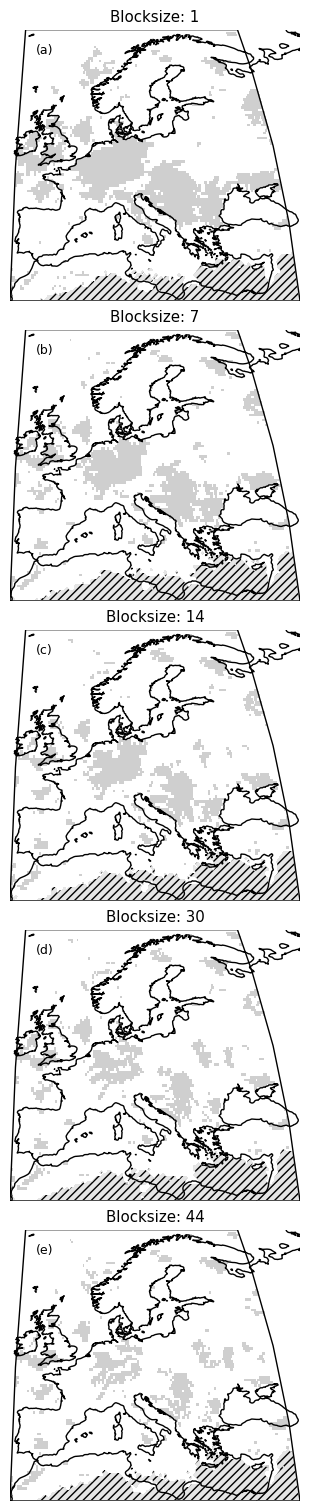

In [27]:
fig, axs = plt.subplots(
    len(p_values.blocksize), 1, subplot_kw=dict(projection=ccrs.Robinson())
)
fig.set_size_inches(6, 15)  # Slightly wider

# 1. Define a specific color for significant values (e.g., a nice Burnt Orange)
significant_color = "#D55E00"

for i, bs in enumerate(p_values.blocksize):
    ax = axs[i]

    # --- BACKGROUND FEATURES ---
    # Add ocean to distinguish sea from non-significant land
    # ax.add_feature(cfeature.OCEAN, facecolor="#Ebf4fa", zorder=0)
    # Add land base (optional, if you want non-significant land to be gray)
    # ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", zorder=0)

    # --- DATA PLOTTING ---
    # Plot ONLY the significant values.
    # We leave non-significant values transparent to let the map show through.
    data = p_values.sel(blocksize=bs).transpose()

    # Create a mask for significant values (p <= 0.05)
    sig_mask = data <= 0.05

    # Plot significant pixels
    # Using pcolormesh is often faster/cleaner for grid data than generic plot()
    map_plot_without_frame_with_bounds(
        ax=ax,
        da=sig_mask.where(sig_mask),
        cmap=plt.matplotlib.colors.ListedColormap(["C9"]),
        add_colorbar=False,
    )

    # --- MISSING DATA HATCHING ---
    nan_mask = data.isnull()
    if nan_mask.any():
        ax.contourf(
            data.coords[data.dims[1]],
            data.coords[data.dims[0]],
            nan_mask.values,
            levels=[0.5, 1.5],
            hatches=["////"],  # Denser, cleaner hatch
            colors="none",  # No background color
            alpha=0.1,
            transform=ccrs.PlateCarree(),
        )

    ax.set_title(f"Blocksize: {bs.values}")

    add_label_to_axes(ax, f"({ALPHABET[i]})", ax_xpos=0.09)

plt.show()


Data has nans in some locations because precipitation is 0 there throughout summer.

# Combined figure

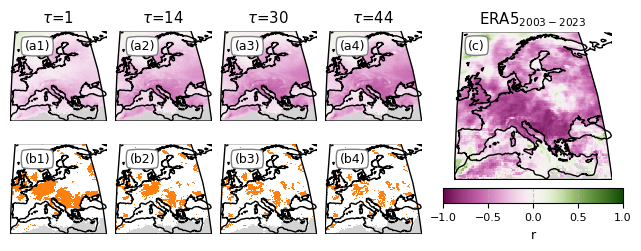

In [28]:
sel_blocksizes = [1, 14, 30, 44]

n_rows = 2
n_cols = len(sel_blocksizes) + 1

fig = plt.figure()

fig.set_figheight(2.4)


gs = gridspec.GridSpec(
    1,
    n_cols,
    width_ratios=(n_cols - 1) * [1] + [2],
    figure=fig,
)

cmap_corr = plt.get_cmap("cmc.bam")
cmap_corr.set_bad(color="lightgray")

colors = ["C1", "white", "lightgray"]  # orange, white, gray
boundaries = [0, 0.05, 1, 2]  # 0-0.05: orange, 0.05-1: white, 1-2: gray (for NaN)
cmap_pvalues = mpl.colors.ListedColormap(colors)
norm_pvalues = mpl.colors.BoundaryNorm(boundaries, cmap_pvalues.N)


for i, bs in enumerate(sel_blocksizes):
    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        1,
        subplot_spec=gs[i],
    )

    ax = fig.add_subplot(gs_sub[0], projection=ccrs.Robinson())

    data = (
        pearsonr.sel(blocksize=bs)
        .transpose()
        .sel(WG="Generated", sigma=2.5, seed=slice(0, None))
        .mean(dim="seed", skipna=False)
        .squeeze()
    )
    m = map_plot_without_frame_with_bounds(
        ax=ax,
        da=data,
        cmap=cmap_corr,
        vmin=-1,
        vmax=1,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    ax.set_title(rf"$\tau$={bs}")

    add_label_to_axes(ax, f"(a{i + 1})", ax_xpos=0.15, ax_ypos=0.9, edgecolor="gray")

    # p values:
    ax = fig.add_subplot(gs_sub[1], projection=ccrs.Robinson())
    data = p_values.sel(blocksize=bs).transpose()

    # Create a mask for significant values (p <= 0.05)
    sig_mask = data.copy()
    sig_mask = sig_mask.where(~np.isnan(sig_mask), 1.5)  # NaN -> 1.5

    # Plot significant pixels
    # Using pcolormesh is often faster/cleaner for grid data than generic plot()
    m = map_plot_without_frame_with_bounds(
        ax=ax,
        da=sig_mask,
        cmap=cmap_pvalues,
        norm=norm_pvalues,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    ax.set_title("")

    add_label_to_axes(ax, f"(b{i + 1})", ax_xpos=0.15, ax_ypos=0.9, edgecolor="gray")


# ground truth
gs_sub = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs[-1], height_ratios=[1, 0.1]
)

ax = fig.add_subplot(gs_sub[0], projection=ccrs.Robinson())
ax_cbar = fig.add_subplot(gs_sub[1])

data = (
    pearsonr.sel(WG="Ground Truth", sigma=-1, seed=-1, blocksize=-1)
    .transpose()
    .squeeze()
)
nan_mask = data.isnull()
m = map_plot_without_frame_with_bounds(
    ax=ax,
    cbar_ax=ax_cbar,
    da=data,
    cmap=cmap_corr,
    vmin=-1,
    vmax=1,
    cbar_kwargs={"orientation": "horizontal", "label": "r"},
    add_colorbar=True,
)
m.set_rasterized(True)


# [r"$\tau=$"+fr"${bs}$" for bs in sel_blocksizes]+[""]
# add_headers(fig, row_headers=["", ""], col_headers=["This", "is", "a", "stupid", "test"])

ax.set_title(r"$\mathrm{ERA5_{2003-2023}}$")

add_label_to_axes(ax, "(c)", ax_xpos=0.09, edgecolor="gray")


plt.savefig(os.path.join(paths["dir_images"], "hot_dry_summary.pdf"), dpi=300)

/tmp/ipykernel_1227719/1384081119.py:213: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon_or = plt.Polygon(
/tmp/ipykernel_1227719/1384081119.py:216: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon_and = plt.Polygon(
/tmp/ipykernel_1227719/1384081119.py:259: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon_or = plt.Polygon(
/tmp/ipykernel_1227719/1384081119.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon_and = plt.Polygon(


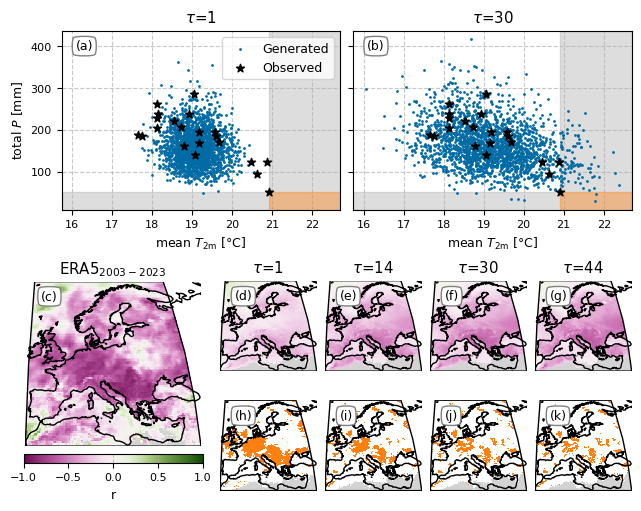

In [29]:
sel_blocksizes = [1, 14, 30, 44]

n_rows = 2
n_cols = len(sel_blocksizes) + 1

fig = plt.figure()

fig.set_figheight(5.0)


gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], figure=fig)

gs_bottom = gs[1].subgridspec(
    1,
    n_cols,
    width_ratios=[2] + (n_cols - 1) * [1],
)

cmap_corr = plt.get_cmap("cmc.bam")
cmap_corr.set_bad(color="lightgray")

colors = ["C1", "white", "lightgray"]  # orange, white, gray
boundaries = [0, 0.05, 1, 2]  # 0-0.05: orange, 0.05-1: white, 1-2: gray (for NaN)
cmap_pvalues = mpl.colors.ListedColormap(colors)
norm_pvalues = mpl.colors.BoundaryNorm(boundaries, cmap_pvalues.N)


for i, bs in enumerate(sel_blocksizes):
    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        1,
        subplot_spec=gs_bottom[i + 1],
    )

    ax = fig.add_subplot(gs_sub[0], projection=ccrs.Robinson())

    data = (
        pearsonr.sel(blocksize=bs)
        .transpose()
        .sel(WG="Generated", sigma=2.5, seed=slice(0, None))
        .mean(dim="seed", skipna=False)
        .squeeze()
    )
    m = map_plot_without_frame_with_bounds(
        ax=ax,
        da=data,
        cmap=cmap_corr,
        vmin=-1,
        vmax=1,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    ax.set_title(rf"$\tau$={bs}")

    add_label_to_axes(
        ax, f"({ALPHABET[3 + i]})", ax_xpos=0.15, ax_ypos=0.9, edgecolor="gray"
    )

    # p values:
    ax = fig.add_subplot(gs_sub[1], projection=ccrs.Robinson())
    data = p_values.sel(blocksize=bs).transpose()

    # Create a mask for significant values (p <= 0.05)
    sig_mask = data.copy()
    sig_mask = sig_mask.where(~np.isnan(sig_mask), 1.5)  # NaN -> 1.5

    # Plot significant pixels
    # Using pcolormesh is often faster/cleaner for grid data than generic plot()
    m = map_plot_without_frame_with_bounds(
        ax=ax,
        da=sig_mask,
        cmap=cmap_pvalues,
        norm=norm_pvalues,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    ax.set_title("")

    add_label_to_axes(
        ax, f"({ALPHABET[7 + i]})", ax_xpos=0.15, ax_ypos=0.9, edgecolor="gray"
    )


# ground truth
gs_sub = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_bottom[0], height_ratios=[1, 0.05]
)

ax = fig.add_subplot(gs_sub[0], projection=ccrs.Robinson())
ax_cbar = fig.add_subplot(gs_sub[1])

data = (
    pearsonr.sel(WG="Ground Truth", sigma=-1, seed=-1, blocksize=-1)
    .transpose()
    .squeeze()
)
nan_mask = data.isnull()
m = map_plot_without_frame_with_bounds(
    ax=ax,
    cbar_ax=ax_cbar,
    da=data,
    cmap=cmap_corr,
    vmin=-1,
    vmax=1,
    cbar_kwargs={"orientation": "horizontal", "label": "r"},
    add_colorbar=True,
)
m.set_rasterized(True)


# [r"$\tau=$"+fr"${bs}$" for bs in sel_blocksizes]+[""]
# add_headers(fig, row_headers=["", ""], col_headers=["This", "is", "a", "stupid", "test"])

ax.set_title(r"$\mathrm{ERA5_{2003-2023}}$")

add_label_to_axes(ax, "(c)", ax_xpos=0.09, edgecolor="gray")

gs_top = gs[0].subgridspec(
    1,
    2,
)

# bottom right:
ax_30 = fig.add_subplot(gs_top[1])
blocksize = 30
# weather generators
for dataset in t2m_summer_trajs.dataset:
    if dataset == "Reforecasts bias-corrected":
        ax_30.scatter(
            t2m_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=blocksize,
                sigma=slice(0, None),
            ),
            tp_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=blocksize,
                sigma=slice(0, None),
            ),
            label="Generated",  # f"Generated {dataset.data}",  #
            s=1,
            zorder=3,
        )
# ground truth
ax_30.scatter(
    t2m_ground_truth,
    tp_ground_truth,
    label="Observed",
    marker="*",
    color="k",
    zorder=4,
)

xlims = ax_30.get_xlim()
ylims = ax_30.get_ylim()

HOTTEST_DRIEST_patch = np.array(
    [
        [
            t2m_ground_truth.max("year").data,
            tp_ground_truth.min("year").data,
        ],
        [
            t2m_ground_truth.max("year").data,
            ylims[0],
        ],
        [
            xlims[1],
            ylims[0],
        ],
        [
            xlims[1],
            tp_ground_truth.min("year").data,
        ],
    ]
)

HOTTEST_DRIEST_or_patch = np.array(
    [
        # Start at bottom-left corner
        [
            xlims[0],
            ylims[0],
        ],
        # Go up to driest precipitation point (left edge)
        [
            xlims[0],
            tp_ground_truth.min("year").data,
        ],
        [
            t2m_ground_truth.max("year").data,
            tp_ground_truth.min("year").data,
        ],
        [
            t2m_ground_truth.max("year").data,
            ylims[1],
        ],
        [
            xlims[1],
            ylims[1],
        ],
        [
            xlims[1],
            ylims[0],
        ],
    ]
)
# Create the OR polygon patch
polygon_or = plt.Polygon(
    HOTTEST_DRIEST_or_patch, color="C2", alpha=0.4, edgecolor="none", zorder=1
)
polygon_and = plt.Polygon(
    HOTTEST_DRIEST_patch, color="C1", alpha=0.4, edgecolor="none", zorder=2
)
ax_30.add_patch(polygon_or)
ax_30.add_patch(polygon_and)

add_label_to_axes(ax_30, "(b)", edgecolor="gray")

# plt.title(f"Months {MONTHS}, elemental timestep: {blocksize}")

# bottom left
ax_1 = fig.add_subplot(gs_top[0], sharex=ax_30, sharey=ax_30)
blocksize = 1
# weather generators
for dataset in t2m_summer_trajs.dataset:
    if dataset == "Reforecasts bias-corrected":
        ax_1.scatter(
            t2m_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=blocksize,
                sigma=slice(0, None),
            ),
            tp_summer_trajs.sel(
                dataset=dataset,
                seed=slice(0, None),
                blocksize=blocksize,
                sigma=slice(0, None),
            ),
            label="Generated",  # f"Generated {dataset.data}",  #
            s=1,
            zorder=3,
        )
# ground truth
ax_1.scatter(
    t2m_ground_truth,
    tp_ground_truth,
    label="Observed",
    marker="*",
    color="k",
    zorder=4,
)

polygon_or = plt.Polygon(
    HOTTEST_DRIEST_or_patch, color="C2", alpha=0.4, edgecolor="none", zorder=1
)
polygon_and = plt.Polygon(
    HOTTEST_DRIEST_patch, color="C1", alpha=0.4, edgecolor="none", zorder=2
)
ax_1.add_patch(polygon_or)
ax_1.add_patch(polygon_and)

add_label_to_axes(ax_1, "(a)", edgecolor="gray")

ax_30.set_xlim(xlims)
ax_30.set_ylim(ylims)

ax_1.set_xlim(xlims)
ax_1.set_ylim(ylims)


ax_1.set_ylabel(r"total $P$ [mm]")
ax_30.set_xlabel(r"mean $T_\mathrm{2m}$ [°C]")
# ax_30.set_yticklabels([])
ax_30.tick_params(labelleft=False)
ax_1.set_xlabel(r"mean $T_\mathrm{2m}$ [°C]")

ax_30.set_title(r"$\tau$=30")
ax_1.set_title(r"$\tau$=1")
ax_1.legend()

"""    if i == 0:
        ax_30.set_ylabel(r"total $P$ [mm]")
    else:
        ax_30.set_yticklabels([])
    ax_30.set_title(r"$\tau$" + f"={blocksize}d")
    ax_30.set_xlabel(r"mean $T_{2m}$ [°C]")
    

if i == 1:
    ax = fig.add_subplot(gs_top[i], sharey=ax_30, sharex=ax_30)
else:"""

plt.savefig(os.path.join(paths["dir_images"], "hot_dry_summary_summary.pdf"), dpi=300)

### What fraction of non-nan grid cells is significantly different?

i.e., in how many grid cells is the p value computed from the ranks smaller than 0.05?

In [30]:
for i, bs in enumerate(sel_blocksizes):
    data = (
        pearsonr.sel(blocksize=bs)
        .transpose()
        .sel(WG="Generated", sigma=2.5, seed=slice(0, None))
        .mean(dim="seed", skipna=False)
        .squeeze()
    )
    data = p_values.sel(blocksize=bs).transpose()
    sig_mask = data.copy()
    fraction = (
        (sig_mask < 0.05).sum() / sig_mask.notnull().sum()
    )  # comparison is False for nans, so doesn't influence counting
    print(f"{bs}: {fraction * 100:.1f}%")
    # sig_mask = sig_mask.where(~np.isnan(sig_mask), 1.5)  # NaN -> 1.5

1: 18.0%
14: 11.5%
30: 10.0%
44: 9.1%
